# Lagged regressors

NeuralProphet是一个可分解的时间序列模型，和上一版FBProphet相比，相似的组成部分有趋势(trend)、季节性(seasonality)、自回归(auto-regression)、特殊事件(special events)，不同之处在于引入了未来回归项(future regressors)和滞后回归项(lagged regressors)。


未来回归项（future-known regressors）是指在预测期有已知未来值的外部变量，而滞后回归项（lagged covariates）是指那些只有观察期值的外部变量。趋势trend可以通过设置变化点来建立线性或组合多个线性趋势的模型。季节性seasonality使用傅里叶项建模，因此可以处理高频率数据的多种季节性。自回归项（auto-regression）使用AR-Net的实现来处理，这是一个用于时间序列的自回归前馈神经网络(Auto-Regressive Feed-Forward Neural Network)。滞后回归项也使用单独的前馈神经网络进行建模。未来回归项和特殊事件都是作为模型的协变量，只需要single weight进行建模。

In [1]:
import pandas as pd

# Load the dataset for tutorial 4 with the extra temperature column
df = pd.read_csv('./data/SF_temperature&hospital_load.csv')
df.head()

,ds,y,temperature
0,2015-01-01,64.92,277.00
1,2015-01-02,58.46,277.95
2,2015-01-03,63.35,278.83
3,2015-01-04,50.54,279.64
4,2015-01-05,64.89,279.05


In [2]:
# Optional:To align the scale of temperature with the energy price, we convert it to Farenheit:
df["temperature"] = (df["temperature"] - 273.15) * 1.8 + 32

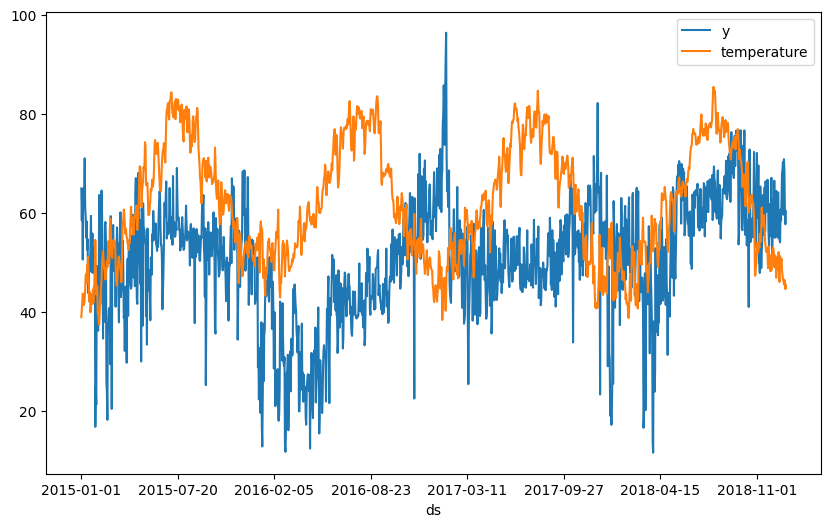

In [3]:
fig = df.plot(x="ds", y=["y", "temperature"], figsize=(10, 6))

In [4]:
from neuralprophet import NeuralProphet, set_log_level

# Disable logging messages unless there is an error
set_log_level("ERROR")

# Model and prediction
m = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_lags=10,  # Autogression
)
m.set_plotting_backend("plotly-static")

# Add temperature of last three days as lagged regressor
m.add_lagged_regressor("temperature", n_lags=3)

# Continue training the model and making a prediction
metrics = m.fit(df)
forecast = m.predict(df)

d:\Neural_Networks\envs\timeseries\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)



Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.

Finding best initial lr: 100%|██████████| 229/229 [00:02<00:00, 108.84it/s]


Training: |          | 0/? [00:39<?, ?it/s, v_num=56, train_loss=0.0174, reg_loss=0.000, MAE=5.000, RMSE=6.680, Loss=0.0175, RegLoss=0.000]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARN


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 48.91it/s]


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




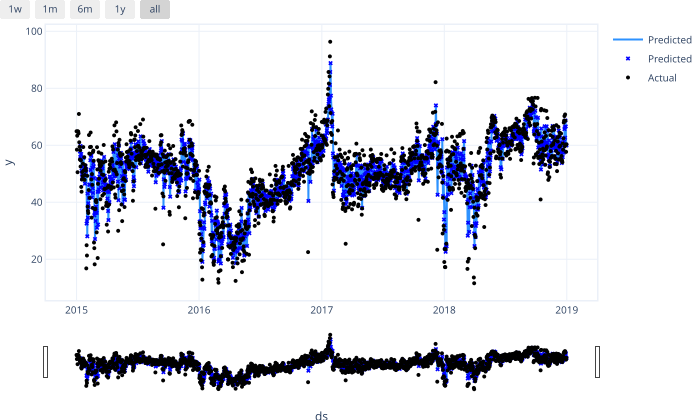

In [11]:
# set plotting to focus on forecasting horizon 1 (the only one for us here)
m.set_plotting_backend("plotly-static")
m.highlight_nth_step_ahead_of_each_forecast(1)
m.plot(forecast)

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:559: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




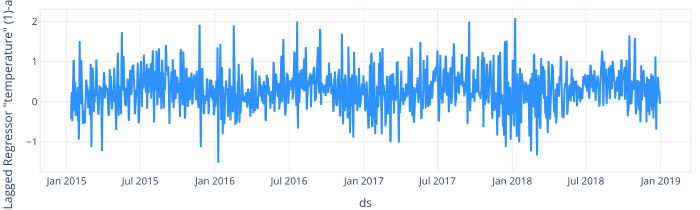

In [6]:
# show the component's forecast contribution
m.plot_components(forecast, components=["lagged_regressors"])

In [7]:
metrics

,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss,epoch
0,1.468745,0.0,127.747849,158.338516,1.468045,0.0,0
1,0.954179,0.0,85.012474,106.646889,0.954381,0.0,1
2,0.605637,0.0,55.126102,68.965378,0.605911,0.0,2
3,0.396771,0.0,37.388309,45.871239,0.395993,0.0,3
4,0.252809,0.0,26.126667,32.004704,0.253342,0.0,4
...,...,...,...,...,...,...,...
95,0.017367,0.0,4.972042,6.642756,0.017242,0.0,95
96,0.017375,0.0,4.955682,6.595048,0.017178,0.0,96
97,0.017363,0.0,4.991282,6.673625,0.017415,0.0,97
98,0.017355,0.0,4.965293,6.623489,0.017177,0.0,98


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.




Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\pytorch_lightning\utilities\data.py:78: UserWarning:

Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 9. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Finding best initial lr: 100%|██████████| 227/227 [00:02<00:00, 96.89it/s]


Training: |          | 0/? [00:37<?, ?it/s, v_num=57, train_loss=0.0183, reg_loss=0.000, MAE=4.740, RMSE=6.400, Loss=0.018, RegLoss=0.000] 

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use 


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 143.22it/s]

WARNING - (py.warnings._showwarnmsg) - d:\Neural_Networks\envs\timeseries\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




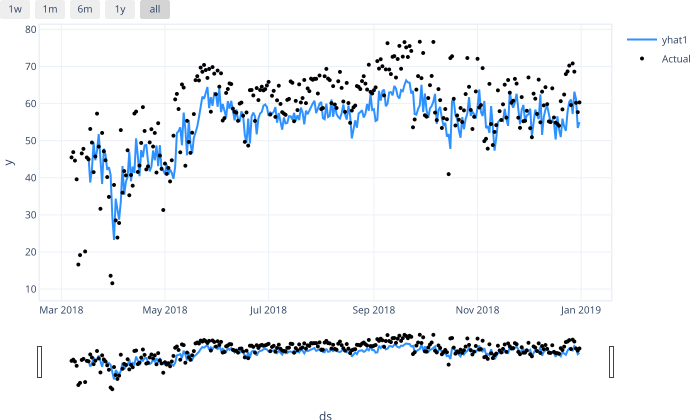

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

# Model and prediction
m = NeuralProphet(
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_lags=10,  # Autogression
)
m.set_plotting_backend("plotly-static")

# Add temperature of last three days as lagged regressor
m.add_lagged_regressor("temperature", n_lags=3)

ts_train, ts_test = m.split_df(df, valid_p = 0.2, local_split = True)
metrics = m.fit(ts_train)
forecast_test = m.predict(ts_test)
last_day = 60
m.plot(forecast_test)

In [9]:
print(f'mean_absolute_percentage_error for last {last_day} days is:')
print(mean_absolute_percentage_error(df.set_index('ds')['y'].iloc[-last_day:], forecast_test.set_index('ds')['yhat1'].iloc[-last_day:]))

mean_absolute_percentage_error for last 60 days is:
0.08250719672073596
